In [2]:
import xarray as xr
from pathlib import Path

In [7]:
# set file path to storage
storage_path = Path("/scratch/dlhogan/ess-project-data/domain_butte_snotel/forcing/SUMMA_input/")

In [6]:
# iterate through the files in the storage path
files_to_remove_for_variable_issues = []
files_to_remove_for_file_opening_issues = []
for file in storage_path.glob("ERA5_surface_*.nc"):
    # test if the file can be opened
    try:
        ds = xr.open_dataset(file)
        # if successful, test if the file has more than 1 variable
        if len(ds.data_vars) > 1:
            continue  # skip files with more than 1 variable
        else:
            files_to_remove_for_variable_issues.append(file)
    except Exception as e:
        # if an error occurs, add the file to the list for file opening issues
        files_to_remove_for_file_opening_issues.append(file)

In [7]:
len(files_to_remove_for_variable_issues), len(files_to_remove_for_file_opening_issues)

(0, 0)

In [43]:
# now move each of these files to the /archive directory
archive_path = storage_path / "archive"
archive_path.mkdir(exist_ok=True)

for file in files_to_remove_for_variable_issues + files_to_remove_for_file_opening_issues:
    file.rename(archive_path / file.name)
    print(f"Moved {file.name} to archive.")

Moved ERA5_surface_200001.nc to archive.
Moved ERA5_surface_200002.nc to archive.
Moved ERA5_surface_200101.nc to archive.
Moved ERA5_surface_200102.nc to archive.
Moved ERA5_surface_200103.nc to archive.
Moved ERA5_surface_200201.nc to archive.
Moved ERA5_surface_200202.nc to archive.
Moved ERA5_surface_200301.nc to archive.
Moved ERA5_surface_200302.nc to archive.
Moved ERA5_surface_200303.nc to archive.
Moved ERA5_surface_200401.nc to archive.
Moved ERA5_surface_200402.nc to archive.
Moved ERA5_surface_200308.nc to archive.
Moved ERA5_surface_200012.nc to archive.
Moved ERA5_surface_199712.nc to archive.
Moved ERA5_surface_200009.nc to archive.
Moved ERA5_surface_200210.nc to archive.
Moved ERA5_surface_200311.nc to archive.
Moved ERA5_surface_200109.nc to archive.
Moved ERA5_surface_200312.nc to archive.
Moved ERA5_surface_199912.nc to archive.
Moved ERA5_surface_199811.nc to archive.
Moved ERA5_surface_200410.nc to archive.
Moved ERA5_surface_199810.nc to archive.
Moved ERA5_surfa

In [16]:
# compare forcing datasets
storage_path_2 = Path("/storage/dlhogan/ess_project_data/domain_East_River/forcing/basin_averaged_data")
ds_original = xr.open_dataset(storage_path_2 / "East_River_ERA5_remapped_domain_East_River_ERA5_merged_198104.nc")
ds_new = xr.open_dataset(storage_path / "butte_snotel_ERA5_remapped_ERA5_merged_198104.nc")

ds_not_merged = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_butte_snotel/forcing/raw_data/ERA5_pressureLevel137_198101.nc")

In [10]:
import matplotlib.pyplot as plt

In [14]:
import rioxarray as rxr
import geopandas as gpd
import pandas as pd

In [12]:
gdf = gpd.read_file("/scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment_intersection/with_dem/catchment_with_dem.shp")


In [18]:
df = pd.read_csv('/scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment_intersection/with_forcing/butte_snotel_ERA5_intersected_shapefile.csv')
df[['S_2_elev_m','S_1_elev_m']]

,S_2_elev_m,S_1_elev_m
0,-9999,2957.136711
1,-9999,2957.136711
2,-9999,2957.136711
3,-9999,2957.136711
4,-9999,2957.136711
5,-9999,2957.136711
6,-9999,2957.136711
7,-9999,2957.136711
8,-9999,2957.136711
9,-9999,2957.136711


Variable latitude not found in new dataset.
Variable longitude not found in new dataset.
Variable hruId not found in new dataset.
Variable spechum not found in new dataset.
Variable windspd not found in new dataset.


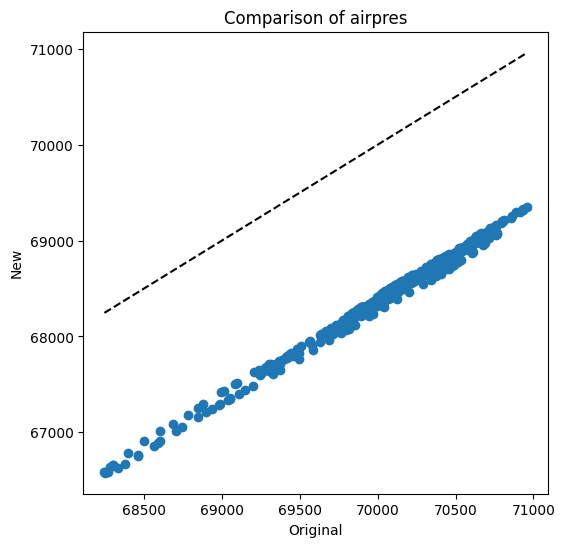

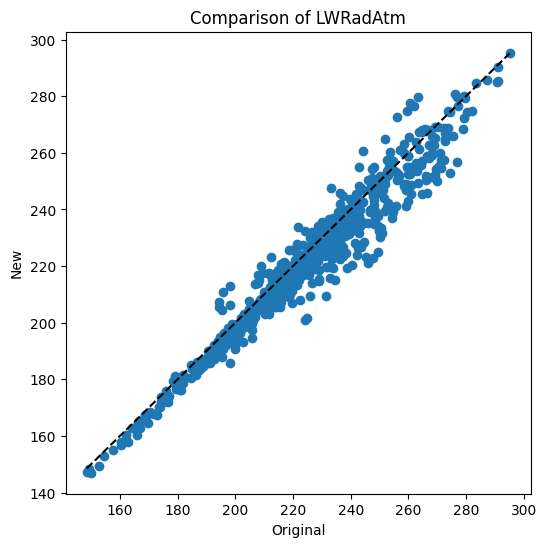

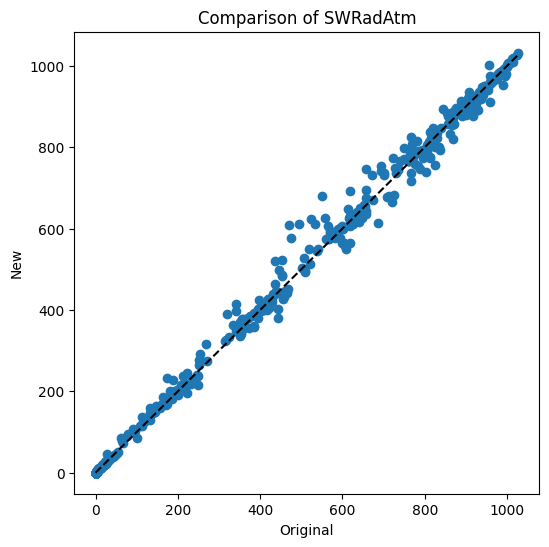

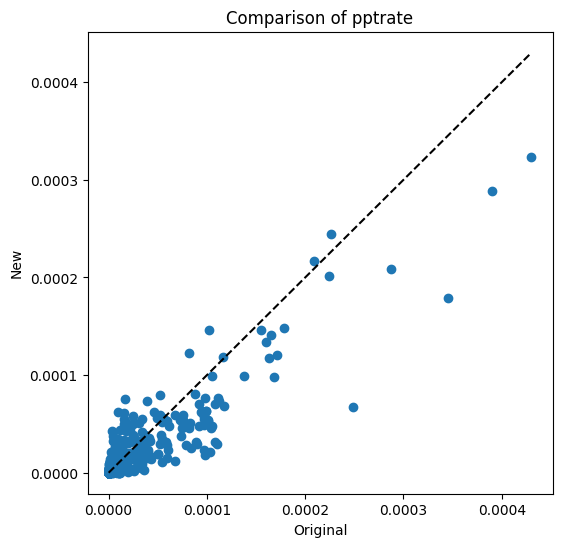

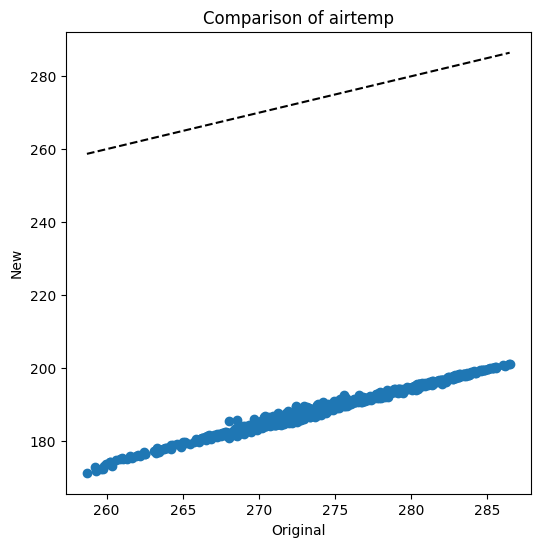

In [14]:
# compare each variable in the datasets
for var in ds_original.data_vars:
    if var in ['airpres', 'LWRadAtm', 'SWRadAtm', 'pptrate', 'airtemp']:
        plt.figure(figsize=(6, 6))
        plt.scatter(ds_original[var].values, ds_new[var].values)
        plt.plot([ds_original[var].min(), ds_original[var].max()], [ds_original[var].min(), ds_original[var].max()], 'k--')
        plt.xlabel("Original")
        plt.ylabel("New")
        plt.title(f"Comparison of {var}")
    else:
        print(f"Variable {var} not found in new dataset.")